# import package

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score
import argparse
import logging
import itertools
import contextlib
import io

import tensorflow as tf
from tensorflow.python.keras import layers
from VAE_learning_dynamics.vae_ld.models.losses import BernoulliLoss, MSELoss
from VAE_learning_dynamics.vae_ld.models import logger
from VAE_learning_dynamics.vae_ld.models.decoders import DeconvolutionalDecoder, FullyConnectedPriorDecoder
from VAE_learning_dynamics.vae_ld.models.divergences import KLD
from VAE_learning_dynamics.vae_ld.models.encoders import ConvolutionalEncoder, FullyConnectedPriorEncoder, ConvolutionalIdentifiableEncoder
from VAE_learning_dynamics.vae_ld.models.vae_utils import compute_batch_tc, compute_covariance

import optuna
from optuna.visualization import plot_optimization_history
import optuna.trial as trial

# import data

In [11]:
df_org = pd.read_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/data15000.csv")
df_org = df_org[df_org["Unnamed: 0"]<4000]
df = df_org.drop(columns=["Unnamed: 0","propensity"])
df_train, df_test = train_test_split(df,test_size=0.2,train_size=0.8,random_state=62619,shuffle=True)
feature_cols = [f'X{j}' for j in range(1, 16)]

X = df[feature_cols].values
t = torch.tensor(df['Treat'].values, dtype=torch.float32)
y = torch.tensor(df['outcome'].values, dtype=torch.float32)
true_ite = torch.tensor(df['ite'].values, dtype=torch.float32)

x_train = df_train[feature_cols].values
t_train = torch.tensor(df_train['Treat'].values, dtype=torch.float32)
y_train = torch.tensor(df_train['outcome'].values, dtype=torch.float32)
true_ite_train = torch.tensor(df_train['ite'].values, dtype=torch.float32)

x_test = df_test[feature_cols].values
t_test = torch.tensor(df_test['Treat'].values, dtype=torch.float32)
y_test = torch.tensor(df_test['outcome'].values, dtype=torch.float32)
true_ite_test = torch.tensor(df_test['ite'].values, dtype=torch.float32)

In [12]:
df_org.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/data4000.csv",index_label=False)

In [13]:
df

,outcome,ite,Treat,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15
0,5.968565,2.914008,0,0.498996,-0.744683,0.631583,-2.250931,0.440648,-0.626338,-1.742961,-0.213154,0.130035,0.756707,-0.418311,-0.278985,-1.090638,0.110575,-1.308545
1,6.134561,2.453375,1,-0.125312,-0.518729,-0.779559,0.790325,0.153279,0.237949,0.093872,-0.281669,-1.150970,1.153764,1.113450,-0.037109,-0.582139,-0.932467,-1.115793
2,5.434231,1.649285,1,0.624574,-0.547371,0.382709,1.812466,-0.423457,0.709234,0.544784,0.753808,0.225651,0.217264,-1.259466,0.007245,1.281948,0.056895,0.051544
3,8.769212,0.418414,1,-0.600122,0.155275,0.156620,1.767312,-0.567372,0.010611,-0.946395,-0.769250,-2.155237,-1.322434,0.604629,-0.013851,0.591109,0.139170,-0.222792
4,4.669871,2.219805,1,0.221132,-1.266828,-0.601818,2.856622,-0.257189,-0.662338,-0.445370,0.011955,-0.492614,0.283331,-0.142223,0.935031,-0.884674,-0.437936,1.115961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,6.571490,0.530887,1,-0.504559,1.583257,-1.157001,-0.156340,-0.767799,1.344220,1.188112,0.816112,1.191594,1.055213,-0.241389,-0.241210,-0.265172,0.669430,-0.111511
3996,7.374402,1.216293,0,0.424793,0.362641,-0.422461,-0.237089,-0.249441,-1.231789,-0.045731,0.668818,0.055830,-0.770000,-1.133428,-1.483931,0.268822,1.058359,-0.154608
3997,11.655357,1.332465,0,-0.921803,-0.278174,-0.404596,-0.563330,-0.529909,0.298827,0.642904,0.224353,0.224668,-0.844014,-2.782974,-0.697358,0.179638,-0.599112,0.970186
3998,6.575889,1.777537,0,0.919948,-1.581522,-0.554908,1.428936,0.088896,1.910908,0.669167,-0.944792,0.491078,-0.063434,0.846724,-1.008446,-0.671280,-1.146422,-0.112417


# Data setting

In [14]:
# Standardize covariates (fit on train only)
# col7-col25 is binary
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
X = scaler.transform(X)

# Convert to PyTorch tensors and DataLoaders
X = torch.from_numpy(X).float()
x_train = torch.from_numpy(x_train).float()
x_test  = torch.from_numpy(x_test).float()

ym, ys = y_train.mean(), y_train.std()
# ym=0
# ys=1
y_train = (y_train - ym) / ys
y_test = (y_test - ym) / ys

-------------------------------------------------------------------------------------------------------------------------------------------------

# R-risk nuisances hyperparameters estimates

e(X) estimate

In [5]:
from pycaret.classification import *

x_name = df_train.columns
t_name = x_name[2]
x_name = x_name.drop(["outcome",'ite',"Treat"])
datat = pd.DataFrame(t_train)
datat = datat.rename(columns={0:t_name})
datax = pd.DataFrame(x_train)
datax.columns = x_name
data_e = pd.concat([datat,datax],axis=1)
data_e["Treat"] = data_e["Treat"].astype("category")

In [6]:
exp = setup(data= data_e,target="Treat",fold=5,session_id=805619)

,Description,Value
0,Session id,805619
1,Target,Treat
2,Target type,Binary
3,Original data shape,"(3200, 16)"
4,Transformed data shape,"(3200, 16)"
5,Transformed train set shape,"(2240, 16)"
6,Transformed test set shape,"(960, 16)"
7,Numeric features,15
8,Preprocess,True
9,Imputation type,simple


In [7]:
add_metric(
    id='ce',
    name='CrossEntropy',
    score_func=log_loss,
    target="pred_proba",
    greater_is_better=False
)

Name                                                      CrossEntropy
Display Name                                              CrossEntropy
Score Function       <pycaret.internal.metrics.EncodedDecodedLabels...
Scorer               make_scorer(log_loss, greater_is_better=False,...
Target                                                      pred_proba
Args                                                                {}
Greater is Better                                                False
Multiclass                                                        True
Custom                                                            True
Name: ce, dtype: object

In [8]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [9]:
#best_model = compare_models(sort="CrossEntropy",turbo=False)

In [10]:
a = models()
all_model_names = a["Name"].index

tuned_results = []
for name in all_model_names:
    try:
        print("")
        print("===========================================")
        print(name)
        model = create_model(name)
        tuned = tune_model(model, optimize='ce',search_library="optuna", n_iter=300)
        cv_results = pull()
        logloss = cv_results['CrossEntropy'].values[5]
        tuned_results.append({'Model': name, 'LogLoss': logloss, 'TunedModel': tuned})
    except Exception as e:
        print(f"{name} failed: {e}")

import pandas as pd
results_df = pd.DataFrame(tuned_results)
results_df = results_df.sort_values('LogLoss')


lr


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CrossEntropy
Fold,,,,,,,,
0,0.7299,0.8075,0.7342,0.7244,0.7293,0.4598,0.4599,0.5354
1,0.7031,0.7743,0.7162,0.6943,0.7051,0.4064,0.4066,0.5763
2,0.7411,0.8173,0.7072,0.7548,0.7302,0.4818,0.4828,0.5293
3,0.7076,0.7802,0.7613,0.6842,0.7207,0.4157,0.4183,0.5646
4,0.7388,0.8218,0.7252,0.7419,0.7335,0.4775,0.4777,0.5163
Mean,0.7241,0.8002,0.7288,0.7199,0.7238,0.4483,0.4490,0.5444
Std,0.0158,0.0194,0.0186,0.0270,0.0102,0.0314,0.0311,0.0225


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CrossEntropy
Fold,,,,,,,,
0,0.7321,0.8076,0.7342,0.7277,0.7309,0.4643,0.4643,0.5361
1,0.7054,0.7742,0.7162,0.6974,0.7067,0.4108,0.4110,0.5739
2,0.7411,0.8174,0.7072,0.7548,0.7302,0.4818,0.4828,0.5302
3,0.7076,0.7802,0.7613,0.6842,0.7207,0.4157,0.4183,0.5629
4,0.7388,0.8220,0.7252,0.7419,0.7335,0.4775,0.4777,0.5176
Mean,0.7250,0.8002,0.7288,0.7212,0.7244,0.4500,0.4508,0.5441
Std,0.0154,0.0195,0.0186,0.0266,0.0099,0.0306,0.0302,0.0210


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

...

Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,CrossEntropy
Fold,,,,,,,,
0,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
1,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
2,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
3,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
4,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
Mean,0.5045,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6931
Std,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

2026-02-25 12:45:30,428:67504:INFO::Searching the best hyperparameters using 2240 samples...
2026-02-25 12:45:48,354:67504:INFO::Finished hyperparameter search!


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [15]:
results_df = results_df.iloc[2:]

In [16]:
results_df

,Model,LogLoss,TunedModel
12,gbc,0.5035,"([DecisionTreeRegressor(ccp_alpha=0.0, criteri..."
15,lightgbm,0.5097,LGBMClassifier(bagging_fraction=0.731811004013...
7,mlp,0.5403,"MLPClassifier(activation='logistic', alpha=1.7..."
13,lda,0.5440,LinearDiscriminantAnalysis(covariance_estimato...
0,lr,0.5441,"LogisticRegression(C=0.09885497958670939, clas..."
9,rf,0.5485,"(DecisionTreeClassifier(ccp_alpha=0.0, class_w..."
2,nb,0.5488,"GaussianNB(priors=None, var_smoothing=1e-09)"
10,qda,0.5489,"QuadraticDiscriminantAnalysis(priors=None, reg..."
14,et,0.5615,"(ExtraTreeClassifier(ccp_alpha=0.0, class_weig..."
5,rbfsvm,0.5620,"SVC(C=0.5554415422511412, break_ties=False, ca..."


In [62]:
best_model = results_df.iloc[0]['TunedModel']
print("Best model:", results_df.iloc[0]['Model'])
final_model_e = finalize_model(best_model)
save_model(final_model_e, "15000data_nuisance_e")
final_model_e = load_model("15000data_nuisance_e")

Best model: gbc
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


In [67]:
best_model

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.27053635245184876, loss='log_loss',
                           max_depth=1, max_features=0.7486441620631877,
                           max_leaf_nodes=None,
                           min_impurity_decrease=7.463588916620843e-08,
                           min_samples_leaf=1, min_samples_split=5,
                           min_weight_fraction_leaf=0.0, n_estimators=252,
                           n_iter_no_change=None, random_state=805619,
                           subsample=0.9481691148326946, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

In [63]:
preds = predict_model(final_model_e, data=datax)
preds["prediction_score"]=preds["prediction_score"]*preds["prediction_label"]+(1-preds["prediction_score"])*(1-preds["prediction_label"])
preds = pd.concat([data_e["Treat"],preds],axis=1)
preds

,Treat,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,prediction_label,prediction_score
0,1.0,0.799953,-0.842970,-0.245062,0.675326,-0.737066,-0.377888,-1.124158,0.402278,-1.333136,-1.122861,-0.032575,-2.265629,0.506853,1.260920,-0.593997,0,0.4840
1,1.0,-0.420251,1.652818,-0.063947,0.611109,1.080132,1.676017,0.431197,0.769835,-0.411232,-1.798421,-0.040167,-1.806993,-0.897104,0.873465,0.916764,1,0.8960
2,1.0,0.010514,-0.361049,1.560644,1.319143,0.315683,0.071982,2.967116,-0.560550,-0.334941,2.048147,0.657236,0.727700,-0.338634,0.094132,0.994507,1,0.9682
3,0.0,0.181328,0.738199,0.103018,-2.874090,-0.362444,-0.712545,1.075393,-1.573396,1.005689,-1.367911,-0.129075,0.447932,-0.899773,1.507542,-1.752565,0,0.0679
4,0.0,0.173176,-1.044240,0.468906,-0.446371,-0.315481,1.676187,-0.844947,0.995860,-1.015530,-0.392430,0.448590,-0.445798,-2.221753,-0.184547,0.800764,1,0.6129
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,1.0,-0.434402,-0.363108,-0.526324,2.406149,-0.583616,0.584640,0.008867,0.252242,-0.669604,-0.578581,0.133447,-1.704687,0.609019,0.627209,-1.464388,1,0.8626
3196,1.0,-0.168923,-0.214512,-0.786734,-0.786216,1.025531,-0.104242,-0.264263,2.118999,2.165862,-1.038209,0.516519,0.240412,1.888214,-1.578562,-1.193178,1,0.7942
3197,1.0,0.004778,1.407211,1.011927,0.193649,-0.068023,2.239731,-0.678989,0.658306,0.736595,-1.099355,-0.708638,0.018794,-1.977123,0.295494,-0.284741,1,0.9541
3198,0.0,0.765437,-0.427477,0.175639,-0.363091,0.099803,-1.000840,-0.082020,-0.259155,0.420996,0.590966,-0.761141,-0.272272,-1.547810,1.244529,-0.278324,0,0.4802


(array([90., 83., 78., 98., 95., 64., 86., 74., 72., 78., 80., 69., 66.,
        67., 76., 78., 93., 86., 88., 86., 61., 88., 93., 97., 90., 86.,
        82., 72., 74., 76., 69., 66., 79., 83., 82., 97., 68., 91., 78.,
        61.]),
 array([7.000000e-04, 2.567250e-02, 5.064500e-02, 7.561750e-02,
        1.005900e-01, 1.255625e-01, 1.505350e-01, 1.755075e-01,
        2.004800e-01, 2.254525e-01, 2.504250e-01, 2.753975e-01,
        3.003700e-01, 3.253425e-01, 3.503150e-01, 3.752875e-01,
        4.002600e-01, 4.252325e-01, 4.502050e-01, 4.751775e-01,
        5.001500e-01, 5.251225e-01, 5.500950e-01, 5.750675e-01,
        6.000400e-01, 6.250125e-01, 6.499850e-01, 6.749575e-01,
        6.999300e-01, 7.249025e-01, 7.498750e-01, 7.748475e-01,
        7.998200e-01, 8.247925e-01, 8.497650e-01, 8.747375e-01,
        8.997100e-01, 9.246825e-01, 9.496550e-01, 9.746275e-01,
        9.996000e-01]),
 <BarContainer object of 40 artists>)

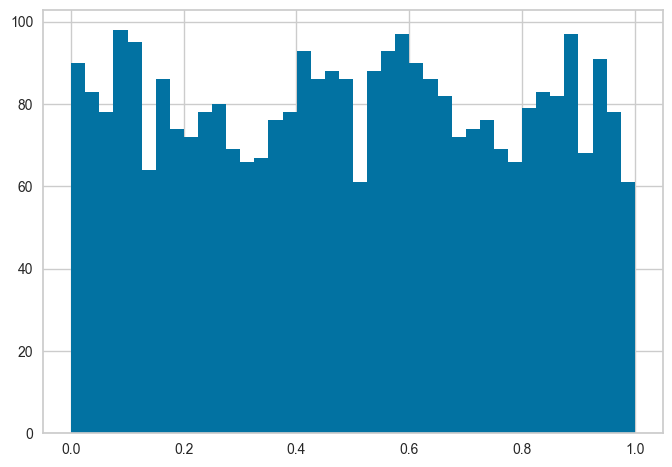

In [64]:
plt.hist(preds["prediction_score"],bins=40)

In [65]:
preds.to_csv("C:/Users/ASUS/Desktop/preds.csv")

In [66]:
print(log_loss(data_e["Treat"],preds["prediction_score"]))
print(accuracy_score(data_e["Treat"],preds["prediction_label"]))

0.4311286197081523
0.80625


m(X) estimate

In [80]:
from pycaret.regression import *

x_name = df_train.columns
y_name = x_name[0]
x_name = x_name.drop(["outcome",'ite',"Treat"])
datay = pd.DataFrame(y_train)
datay = datay.rename(columns={0:y_name})
datax = pd.DataFrame(x_train)
datax.columns = x_name
data_m = pd.concat([datay,datax],axis=1)

In [81]:
exp = setup(data= data_m,target="outcome",fold=5,session_id=805619)

,Description,Value
0,Session id,805619
1,Target,outcome
2,Target type,Regression
3,Original data shape,"(3200, 16)"
4,Transformed data shape,"(3200, 16)"
5,Transformed train set shape,"(2240, 16)"
6,Transformed test set shape,"(960, 16)"
7,Numeric features,15
8,Preprocess,True
9,Imputation type,simple


In [82]:
models()

,Name,Reference,Turbo
ID,,,
lr,Linear Regression,sklearn.linear_model._base.LinearRegression,True
lasso,Lasso Regression,sklearn.linear_model._coordinate_descent.Lasso,True
ridge,Ridge Regression,sklearn.linear_model._ridge.Ridge,True
en,Elastic Net,sklearn.linear_model._coordinate_descent.Elast...,True
lar,Least Angle Regression,sklearn.linear_model._least_angle.Lars,True
llar,Lasso Least Angle Regression,sklearn.linear_model._least_angle.LassoLars,True
omp,Orthogonal Matching Pursuit,sklearn.linear_model._omp.OrthogonalMatchingPu...,True
br,Bayesian Ridge,sklearn.linear_model._bayes.BayesianRidge,True
ard,Automatic Relevance Determination,sklearn.linear_model._bayes.ARDRegression,False


In [83]:
a = models()
all_model_names = a["Name"].index

tuned_results = []
for name in all_model_names:
    try:
        print("")
        print("===========================================")
        print(name)
        model = create_model(name)
        tuned = tune_model(model, optimize='MSE',search_library="optuna", n_iter=300)
        cv_results = pull()
        MSE = cv_results['MSE'].values[5]
        tuned_results.append({'Model': name, 'MSE': MSE, 'TunedModel': tuned})
    except Exception as e:
        print(f"{name} failed: {e}")

import pandas as pd
results_df = pd.DataFrame(tuned_results)
results_df = results_df.sort_values('MSE')


lr


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7600,0.9054,0.9515,0.0153,0.4944,1.4545
1,0.8227,1.0104,1.0052,0.0126,0.5149,1.7996
2,0.7732,0.9900,0.9950,0.0549,0.5270,1.2309
3,0.7977,1.0431,1.0213,0.0082,0.5186,1.3471
4,0.7733,0.9679,0.9838,0.0080,0.5004,1.3435
Mean,0.7854,0.9834,0.9914,0.0198,0.5111,1.4351
Std,0.0223,0.0462,0.0234,0.0178,0.0120,0.1955


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7595,0.9053,0.9515,0.0154,0.4943,1.4543
1,0.8232,1.0094,1.0047,0.0136,0.5139,1.8139
2,0.7730,0.9899,0.9950,0.0549,0.5269,1.2322
3,0.7985,1.0417,1.0207,0.0095,0.5187,1.3563
4,0.7715,0.9667,0.9832,0.0092,0.5003,1.3277
Mean,0.7851,0.9826,0.9910,0.0205,0.5108,1.4369
Std,0.0229,0.0458,0.0233,0.0174,0.0120,0.2014


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7797,0.9204,0.9594,-0.0010,0.6050,1.0051
1,0.8242,1.0261,1.0130,-0.0027,0.6220,1.0172
2,0.8025,1.0479,1.0236,-0.0004,0.6226,0.9993
3,0.8014,1.0552,1.0273,-0.0034,0.6132,0.9933
4,0.7882,0.9795,0.9897,-0.0039,0.6039,1.0061
Mean,0.7992,1.0058,1.0026,-0.0023,0.6133,1.0042
Std,0.0151,0.0502,0.0253,0.0014,0.0080,0.0080


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,16:34:16
Status,. . . . . . . . . . . . . . . . . .,Searching Hyperparameters
Estimator,. . . . . . . . . . . . . . . . . .,Dummy Regressor


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

dummy failed: parameter grid for tuning is empty. If passing custom_grid, make sure that it is not empty. If not passing custom_grid, the passed estimator does not have a built-in tuning grid.


In [84]:
results_df

,Model,MSE,TunedModel
20,gbr,0.2320,"([DecisionTreeRegressor(ccp_alpha=0.0, criteri..."
21,mlp,0.2442,"MLPRegressor(activation='relu', alpha=0.757935..."
22,lightgbm,0.2459,LGBMRegressor(bagging_fraction=0.8156633329092...
14,svm,0.3436,"SVR(C=1.0, cache_size=200, coef0=0.0, degree=3..."
17,rf,0.5012,"(DecisionTreeRegressor(ccp_alpha=0.0, criterio..."
18,et,0.5092,"(ExtraTreeRegressor(ccp_alpha=0.0, criterion='..."
19,ada,0.6384,"(DecisionTreeRegressor(ccp_alpha=0.0, criterio..."
16,dt,0.6836,"DecisionTreeRegressor(ccp_alpha=0.0, criterion..."
15,knn,0.9433,"KNeighborsRegressor(algorithm='auto', leaf_siz..."
6,omp,0.9779,"OrthogonalMatchingPursuit(fit_intercept=False,..."


In [95]:
best_model = results_df.iloc[0]['TunedModel']
print("Best model:", results_df.iloc[0]['Model'])
final_model_m = finalize_model(best_model)
save_model(final_model_m, "15000data_nuisance_m")
final_model_m = load_model("15000data_nuisance_m")

Best model: gbr
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Loaded


In [96]:
best_model

GradientBoostingRegressor(alpha=0.9, ccp_alpha=0.0, criterion='friedman_mse',
                          init=None, learning_rate=0.42123173798837793,
                          loss='squared_error', max_depth=1,
                          max_features=0.7581525897316964, max_leaf_nodes=None,
                          min_impurity_decrease=2.940545844813572e-09,
                          min_samples_leaf=5, min_samples_split=7,
                          min_weight_fraction_leaf=0.0, n_estimators=228,
                          n_iter_no_change=None, random_state=805619,
                          subsample=0.9757482902722159, tol=0.0001,
                          validation_fraction=0.1, verbose=0, warm_start=False)

In [97]:
preds = predict_model(final_model_m, data=datax)
preds = pd.concat([data_m["outcome"],preds],axis=1)
preds

,outcome,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,prediction_label
0,0.681881,0.799953,-0.842970,-0.245062,0.675326,-0.737066,-0.377888,-1.124158,0.402278,-1.333136,-1.122861,-0.032575,-2.265629,0.506853,1.260920,-0.593997,0.264301
1,1.053316,-0.420251,1.652818,-0.063947,0.611109,1.080132,1.676017,0.431197,0.769835,-0.411232,-1.798421,-0.040167,-1.806993,-0.897104,0.873465,0.916764,0.752930
2,1.333597,0.010514,-0.361049,1.560644,1.319143,0.315683,0.071982,2.967116,-0.560550,-0.334941,2.048147,0.657236,0.727700,-0.338634,0.094132,0.994507,1.496061
3,-0.519001,0.181328,0.738199,0.103018,-2.874090,-0.362444,-0.712545,1.075393,-1.573396,1.005689,-1.367911,-0.129075,0.447932,-0.899773,1.507542,-1.752565,-0.378743
4,-0.723251,0.173176,-1.044240,0.468906,-0.446371,-0.315481,1.676187,-0.844947,0.995860,-1.015530,-0.392430,0.448590,-0.445798,-2.221753,-0.184547,0.800764,-0.180995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3195,-0.585998,-0.434402,-0.363108,-0.526324,2.406149,-0.583616,0.584640,0.008867,0.252242,-0.669604,-0.578581,0.133447,-1.704687,0.609019,0.627209,-1.464388,-0.503776
3196,2.339520,-0.168923,-0.214512,-0.786734,-0.786216,1.025531,-0.104242,-0.264263,2.118999,2.165862,-1.038209,0.516519,0.240412,1.888214,-1.578562,-1.193178,1.356971
3197,0.672170,0.004778,1.407211,1.011927,0.193649,-0.068023,2.239731,-0.678989,0.658306,0.736595,-1.099355,-0.708638,0.018794,-1.977123,0.295494,-0.284741,0.294528
3198,-1.164774,0.765437,-0.427477,0.175639,-0.363091,0.099803,-1.000840,-0.082020,-0.259155,0.420996,0.590966,-0.761141,-0.272272,-1.547810,1.244529,-0.278324,-1.017450


-------------------------------------------------------------------------------------------------------------------------------------------------

# EDVAE (optuna)

In [15]:
import pyro
from edvae_gpu_new_cagrad import EDVAE_new as EDVAE
# from edvae_gpu_new_cagrad import EDVAE_new_DKL as EDVAE

initial model setting

In [16]:
args = {
    'model_name':"EDVAE",
    'feature_dim': x_train.shape[1],
    'latent_dim': int(x_train.shape[1]/3),
    'latent_dim_t': int(x_train.shape[1]/3),
    'latent_dim_y': int(x_train.shape[1]/3),
    'hidden_dim': 128,
    'num_layers': 4,
    'alpha_t':100.0,
    'alpha_y':100.0, 
    'alpha_d':10.0, 
    'contfeats':list(range(0,15)),
    'binfeats':[],
}

In [17]:
x_name = df_train.columns
x_name = x_name.drop(["outcome",'ite',"Treat"])
datax = pd.DataFrame(x_train)
datax.columns = x_name

from pycaret.classification import *
model_e = load_model("15000data_nuisance_e")
nuisance_e = predict_model(model_e, data=datax)
nuisance_e["prediction_score"] = nuisance_e["prediction_score"]*nuisance_e["prediction_label"]+(1-nuisance_e["prediction_score"])*(1-nuisance_e["prediction_label"])
nuisance_e = np.array(nuisance_e["prediction_score"])

from pycaret.regression import *
model_m = load_model("15000data_nuisance_m")
nuisance_m = predict_model(model_m, data=datax)
nuisance_m = np.array(nuisance_m["prediction_label"])

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [18]:
import optuna
from optuna.visualization import plot_optimization_history
import optuna.trial as trial

def objective(trial, x_train=x_train, t_train=t_train, y_train=y_train, true_ite_train=true_ite_train, ym=ym, ys=ys, args=args, 
              nuisance_e=nuisance_e, nuisance_m=nuisance_m):

    # split data to training & validation
    np.random.seed(61985)
    val_split = 0.25
    size = int(x_train.shape[0]*(1-val_split))
    ind = np.random.permutation(np.array(list(range(x_train.shape[0]))))
    ind_tr = ind[:size]
    ind_te = ind[size:]
    x_train_tr = x_train[ind_tr,:]
    t_train_tr = t_train[ind_tr]
    y_train_tr = y_train[ind_tr]
    x_train_te = x_train[ind_te,:]
    t_train_te = t_train[ind_te]
    y_train_te = y_train[ind_te]
    true_ite_train_te = true_ite_train[ind_te]
    e_te = nuisance_e[ind_te]
    m_te = nuisance_m[ind_te]
    m_te = m_te*np.array(ys)+np.array(ym)

    params = {
        'latent_dim': trial.suggest_int('latent_dim', 1, x_train.shape[1]*2/3, 1),
        "latent_dim_t": trial.suggest_int("latent_dim_t", 1, x_train.shape[1]*2/3, 1),
        'latent_dim_y': trial.suggest_int('latent_dim_y', 1, x_train.shape[1]*2/3, 1),
        'hidden_dim': trial.suggest_float('hidden_dim', 3, 10),
        'num_layers': trial.suggest_int('num_layers', 2, 5, 1),
        'alpha_t': trial.suggest_float('alpha_t', -3, 4),
        "alpha_y": trial.suggest_float("alpha_y", 0, 4),
        'alpha_d': trial.suggest_float('alpha_d', -3, 4),
        'batch_size': trial.suggest_int('batch_size', 8, 10, 1),
        "weight_decay": trial.suggest_int("weight_decay", -6, -1, 1),
        'learning_rate': trial.suggest_float('learning_rate', -6, -2),
    }
    
    # training for loss weights
    pyro.set_rng_seed(2619)
    pyro.clear_param_store()
    edvae = EDVAE(feature_dim=args["feature_dim"], continuous_dim = args["contfeats"], binary_dim = args["binfeats"],
                  latent_dim=params["latent_dim"], latent_dim_t = params["latent_dim_t"], latent_dim_y = params["latent_dim_y"],
                  hidden_dim=int(2**params["hidden_dim"]),
                  num_layers=params["num_layers"],
                  num_samples=500, 
                  alpha_t=round(10**params['alpha_t'],2), 
                  alpha_y=round(10**params['alpha_y'],2),
                  alpha_d=round(10**params['alpha_d'],2))
    with contextlib.redirect_stdout(io.StringIO()):
        edvaefit, grad_elbo, trn_edvaefit, val_edvaefit, edvaefit_t, grad_t, trn_edvaefit_t, val_edvaefit_t, \
        edvaefit_y, grad_y, trn_edvaefit_y, val_edvaefit_y, edvaefit_d, grad_d, trn_edvaefit_d, val_edvaefit_d, \
        loss_weights_record = edvae.fit(x_train_tr, t_train_tr, y_train_tr, x_train_te, t_train_te, y_train_te,
                                        num_epochs=1000,
                                        batch_size=2**params["batch_size"],
                                        learning_rate=10**params["learning_rate"],
                                        weight_decay=round(10**params["weight_decay"],5))
    
    # Evaluate
    est_ite,est_y0,est_y1,est_t,muz_hat,muzt_hat,muzy_hat,ite_gen,t_gen,y0gen,y1gen,TC_list= edvae.ite(x_train_te, ym, ys)

    pehe_valid = np.sqrt(np.mean((true_ite_train_te.numpy().squeeze()-est_ite.numpy().squeeze())**2))
    mu = np.array(est_y1)*np.array(t_train_te) + np.array(est_y0)*(1-np.array(t_train_te))
    mse = np.mean((np.array(y_train_te*ys + ym) -mu)**2)
    CE = log_loss(np.array(t_train_te),np.array(est_t))

    # R-risk
    R_risk = np.mean(((np.array(y_train_te*ys + ym)-m_te)-(np.array(t_train_te)-e_te)*(est_ite.numpy().squeeze()))**2)

    # mu-risk-ce
    a = (np.array(y_train_te*ys + ym) -mu)**2
    b = -(np.array(t_train_te)*np.log(np.array(est_t))+(1-np.array(t_train_te))*np.log(1-np.array(est_t)))+1
    mu_risk_ce = np.mean(a*b)

    trial.set_user_attr("pehe", pehe_valid)
    trial.set_user_attr("CE", CE)
    trial.set_user_attr("MSE", mse)
    trial.set_user_attr("mu_risk_ce", mu_risk_ce)

    print(f"pehe={pehe_valid}, MSE={mse}, CE={CE}, R_risk={R_risk}")

    return mu_risk_ce

In [ ]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials = 50)

[I 2026-03-02 10:47:37,707] A new study created in memory with name: no-name-3a100da6-4795-4d35-b097-af933118a854
[I 2026-03-02 10:52:45,730] Trial 0 finished with value: 4.173830032348633 and parameters: {'latent_dim': 7, 'latent_dim_t': 8, 'latent_dim_y': 4, 'hidden_dim': 6.590100045837914, 'num_layers': 3, 'alpha_t': 2.503013920070156, 'alpha_y': 3.897084682654091, 'alpha_d': 0.9820113276194928, 'batch_size': 9, 'weight_decay': -5, 'learning_rate': -3.4475200245247284}. Best is trial 0 with value: 4.173830032348633.


pehe=2.162564516067505, MSE=2.738354444503784, CE=0.5710868493601372, R_risk=2.517407903232855


[I 2026-03-02 10:59:40,185] Trial 1 finished with value: 27.067581176757812 and parameters: {'latent_dim': 3, 'latent_dim_t': 5, 'latent_dim_y': 5, 'hidden_dim': 8.409522999652317, 'num_layers': 6, 'alpha_t': 2.403460125588623, 'alpha_y': -1.4973856924752593, 'alpha_d': -2.7863529206011806, 'batch_size': 8, 'weight_decay': -5, 'learning_rate': -3.2010586188310763}. Best is trial 0 with value: 4.173830032348633.


pehe=2.789630174636841, MSE=17.592008590698242, CE=0.6155326683271193, R_risk=2.9361873644155536


[I 2026-03-02 11:30:04,820] Trial 2 finished with value: 30.101905822753906 and parameters: {'latent_dim': 2, 'latent_dim_t': 1, 'latent_dim_y': 6, 'hidden_dim': 9.268538537682307, 'num_layers': 6, 'alpha_t': 3.11548781391323, 'alpha_y': -1.137429269910201, 'alpha_d': -0.17253965987534592, 'batch_size': 8, 'weight_decay': -5, 'learning_rate': -4.900126236546678}. Best is trial 0 with value: 4.173830032348633.


...

pehe=1.0985232591629028, MSE=1.5609650611877441, CE=0.5866362884114922, R_risk=2.035673519090403


[I 2026-03-04 07:47:57,306] Trial 148 finished with value: 4.683139324188232 and parameters: {'latent_dim': 6, 'latent_dim_t': 10, 'latent_dim_y': 2, 'hidden_dim': 8.603336425639787, 'num_layers': 3, 'alpha_t': 1.3027299035594115, 'alpha_y': 1.0130783595475021, 'alpha_d': -0.17541660120935312, 'batch_size': 10, 'weight_decay': -6, 'learning_rate': -4.196818454840447}. Best is trial 139 with value: 2.042250156402588.


pehe=2.3821074962615967, MSE=2.9310944080352783, CE=0.5873497818338732, R_risk=2.6955105582042616


[I 2026-03-04 08:11:30,639] Trial 149 finished with value: 4.63987922668457 and parameters: {'latent_dim': 8, 'latent_dim_t': 10, 'latent_dim_y': 2, 'hidden_dim': 9.550450279921591, 'num_layers': 3, 'alpha_t': 1.6047143417002219, 'alpha_y': 1.2217900788174272, 'alpha_d': 0.04422734977648268, 'batch_size': 10, 'weight_decay': -6, 'learning_rate': -4.543772105426622}. Best is trial 139 with value: 2.042250156402588.


pehe=2.343611240386963, MSE=2.936671257019043, CE=0.5795663278354833, R_risk=2.6807537452546253


In [10]:
# Showing optimization results
print('Number of finished trials:', len(study.trials))
print('Best trial parameters:', study.best_trial.params)
print('Best score:', study.best_value)

plotly_config = {"staticPlot": True}
fig = plot_optimization_history(study)
fig.show(config=plotly_config)

Number of finished trials: 150
Best trial parameters: {'latent_dim': 8, 'latent_dim_t': 10, 'latent_dim_y': 2, 'hidden_dim': 9.517257582985813, 'num_layers': 3, 'alpha_t': 1.3189120126033766, 'alpha_y': 1.4117688066704297, 'alpha_d': -0.2554320097935826, 'batch_size': 10, 'weight_decay': -6, 'learning_rate': -4.2003187437827645}
Best score: 2.042250156402588


In [11]:
from optuna.visualization import plot_param_importances, plot_contour, plot_parallel_coordinate, plot_edf, plot_pareto_front
fig2 = plot_param_importances(study)
fig2.show(config=plotly_config)

In [12]:
fig3 = plot_contour(study)
fig3.show(config=plotly_config)

In [13]:
fig4 = plot_parallel_coordinate(study)
fig4.show(config=plotly_config)

In [14]:
fig5 = plot_edf(study)
fig5.show(config=plotly_config)

------------------------------------------------------------------------------

In [17]:
study.best_trial.params

{'latent_dim': 8,
 'latent_dim_t': 10,
 'latent_dim_y': 2,
 'hidden_dim': 9.517257582985813,
 'num_layers': 3,
 'alpha_t': 1.3189120126033766,
 'alpha_y': 1.4117688066704297,
 'alpha_d': -0.2554320097935826,
 'batch_size': 10,
 'weight_decay': -6,
 'learning_rate': -4.2003187437827645}

In [44]:
args = {
    'model_name':"EDVAE",
    'feature_dim': x_train.shape[1],
    'latent_dim': study.best_trial.params['latent_dim'],
    'latent_dim_t': study.best_trial.params['latent_dim_t'],
    'latent_dim_y': study.best_trial.params['latent_dim_y'],
    'hidden_dim': int(2**study.best_trial.params['hidden_dim']),
    'num_layers': study.best_trial.params['num_layers'],
    'alpha_t':round(10**study.best_trial.params['alpha_t'],2),
    'alpha_y':round(10**study.best_trial.params['alpha_y'],2), 
    'alpha_d':round(10**study.best_trial.params['alpha_d'],2), 
    'batch_size':2**study.best_trial.params["batch_size"],
    'learning_rate':10**study.best_trial.params["learning_rate"],
    'weight_decay':round(10**study.best_trial.params["weight_decay"],5),
    'contfeats':list(range(0,15)),
    'binfeats':[],
}
args

{'model_name': 'EDVAE',
 'feature_dim': 15,
 'latent_dim': 8,
 'latent_dim_t': 10,
 'latent_dim_y': 2,
 'hidden_dim': 732,
 'num_layers': 3,
 'alpha_t': 20.84,
 'alpha_y': 25.81,
 'alpha_d': 0.56,
 'batch_size': 1024,
 'learning_rate': 6.304944328960015e-05,
 'weight_decay': 0.0,
 'contfeats': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 'binfeats': []}

In [77]:
pyro.set_rng_seed(2619)
pyro.clear_param_store()
edvae = EDVAE(feature_dim=args["feature_dim"], continuous_dim = args["contfeats"], binary_dim = args["binfeats"],
                  latent_dim=args["latent_dim"], latent_dim_t = args["latent_dim_t"], latent_dim_y = args["latent_dim_y"],
                  hidden_dim=args["hidden_dim"],
                  num_layers=args["num_layers"],
                  num_samples=500, alpha_t = args["alpha_t"], alpha_y = args["alpha_y"], alpha_d = args["alpha_d"], cagrad_c = 0)
edvaefit, grad_elbo, trn_edvaefit, val_edvaefit, edvaefit_t, grad_t, trn_edvaefit_t, val_edvaefit_t, \
edvaefit_y, grad_y, trn_edvaefit_y, val_edvaefit_y, edvaefit_d, grad_d, trn_edvaefit_d, val_edvaefit_d, loss_weights_record = \
    edvae.fit(x_train, t_train, y_train, x_test, t_test, y_test, 
              num_epochs=1000,
              batch_size=args["batch_size"],
              learning_rate=args["learning_rate"],
              weight_decay=args["weight_decay"])

# Evaluate.
est_ite,est_y0,est_y1,est_t,muz_hat,muzt_hat,muzy_hat,ite_gen,t_gen,y0gen,y1gen,TC_list= edvae.ite(x_test, ym, ys, Total_correlation=False)
est_ite_all,est_y0_all,est_y1_all,est_t_all,muz_hat_all,muzt_hat_all,muzy_hat_all,ite_gen_all,t_gen_all,y0gen_all,y1gen_all,TC_list_all = edvae.ite(X, ym, ys, Total_correlation=False)

ELBO Loss: 28.9203466796875, t loss : 0.7161482238769531, y loss : 1.6394549560546872 ,Wasserstein Loss: 0.2884489127567836, Total: 86.32073947219848, loss_weights: [0.25, 5.21, 6.4525, 0.14]
ELBO Loss: 28.422712936401368, t loss : 0.7165910339355469, y loss : 1.6091549682617186 ,Wasserstein Loss: 0.28310596942901606, Total: 85.04729915733337, loss_weights: [0.25, 5.21, 6.4525, 0.14]
ELBO Loss: 28.699475555419923, t loss : 0.6894850158691407, y loss : 1.5635343933105468 ,Wasserstein Loss: 0.4994932923998151, Total: 83.70288222122191, loss_weights: [0.25, 5.21, 6.4525, 0.14]
ELBO Loss: 27.933143920898438, t loss : 0.7005564880371093, y loss : 1.4675466918945312 ,Wasserstein Loss: 0.36798279626028874, Total: 80.6161916152954, loss_weights: [0.25, 5.21, 6.4525, 0.14]
ELBO Loss: 27.51360641479492, t loss : 0.6962739562988282, y loss : 1.4318383789062499 ,Wasserstein Loss: 0.3514457089560372, Total: 79.17651382064818, loss_weights: [0.25, 5.21, 6.4525, 0.14]
ELBO Loss: 27.34168518066406, t 

In [78]:
# print(f"test data, TC_zt: {TC_list[0]}")
# print(f"test data, TC_zc: {TC_list[1]}")
# print(f"test data, TC_zy: {TC_list[2]}")
# print(f"test data, TC_zt_zc: {TC_list[3]}")
# print(f"test data, TC_zc_zy: {TC_list[4]}")
# print(f"test data, TC_zt_zy: {TC_list[5]}")
# print(f"test data, TC: {TC_list[6]}")
# print("")
# print(f"all data, TC_zt: {TC_list_all[0]}")
# print(f"all data, TC_zc: {TC_list_all[1]}")
# print(f"all data, TC_zy: {TC_list_all[2]}")
# print(f"all data, TC_zt_zc: {TC_list_all[3]}")
# print(f"all data, TC_zc_zy: {TC_list_all[4]}")
# print(f"all data, TC_zt_zy: {TC_list_all[5]}")
# print(f"all data, TC: {TC_list_all[6]}")

In [79]:
layer_w0=list(edvae.guide.zt_nn.named_parameters())
weights_w0=layer_w0[0][1]
bias_w0=layer_w0[1][1]
layer_c0=list(edvae.guide.z_nn.named_parameters())
weights_c0=layer_c0[0][1]
bias_c0=layer_c0[1][1]
layer_o0=list(edvae.guide.zy_nn.named_parameters())
weights_o0=layer_o0[0][1]
bias_o0=layer_o0[1][1]

instrument_wts=weights_w0.abs().sum(0)
instrument_wts=instrument_wts/((instrument_wts**2).sum().sqrt())
confounder_wts=weights_c0.abs().sum(0)
confounder_wts=confounder_wts/((confounder_wts**2).sum().sqrt())
adjustment_wts=weights_o0.abs().sum(0)
adjustment_wts=adjustment_wts/((adjustment_wts**2).sum().sqrt())

print("instrument block vs covariates")
print(instrument_wts)
print()
print("confounder block vs covariates")
print(confounder_wts)
print()
print("adjustment block vs covariates")
print(adjustment_wts)
print()

print(f"zt vs zc: {(instrument_wts*confounder_wts).sum()}")
print(f"zt vs zy: {(instrument_wts*adjustment_wts).sum()}")
print(f"zc vs zy: {(confounder_wts*adjustment_wts).sum()}")
print(f"total: {(instrument_wts*confounder_wts).sum()+(instrument_wts*adjustment_wts).sum()+(confounder_wts*adjustment_wts).sum()}")

instrument block vs covariates
tensor([0.2589, 0.2613, 0.2641, 0.2558, 0.2580, 0.2645, 0.2481, 0.2646, 0.2612,
        0.2537, 0.2608, 0.2529, 0.2668, 0.2524, 0.2489],
       grad_fn=<DivBackward0>)

confounder block vs covariates
tensor([0.2524, 0.2444, 0.2568, 0.2620, 0.2598, 0.2554, 0.2650, 0.2597, 0.2610,
        0.2582, 0.2649, 0.2519, 0.2606, 0.2512, 0.2688],
       grad_fn=<DivBackward0>)

adjustment block vs covariates
tensor([0.2528, 0.2497, 0.2511, 0.2580, 0.2537, 0.2675, 0.2631, 0.2647, 0.2624,
        0.2634, 0.2515, 0.2642, 0.2546, 0.2528, 0.2625],
       grad_fn=<DivBackward0>)

zt vs zc: 0.9993540048599243
zt vs zy: 0.9993764162063599
zc vs zy: 0.9996371269226074
total: 2.9983675479888916


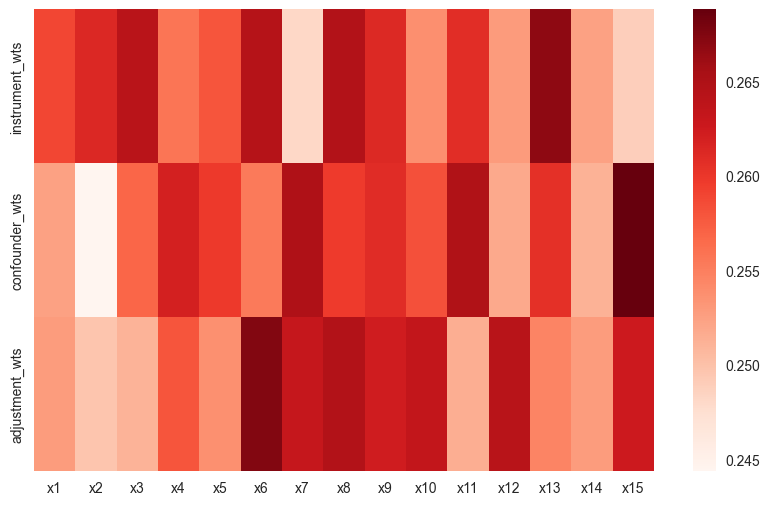

In [80]:
import seaborn as sns
all_latent_wts={"instrument_wts":instrument_wts.detach().numpy(),
                "confounder_wts":confounder_wts.detach().numpy(),
                "adjustment_wts":adjustment_wts.detach().numpy()}
all_latent_wts=pd.DataFrame(all_latent_wts,index=["x1","x2","x3","x4","x5","x6","x7","x8","x9","x10","x11","x12","x13","x14","x15"]).T
plt.rcParams['figure.figsize'] = 10.0, 6.0
sns.heatmap(all_latent_wts,annot_kws={"size":10},cmap="Reds")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

(array([ 2.,  3.,  6., 10.,  9., 12., 17., 22., 24., 16., 19., 29., 16.,
        30., 35., 28., 27., 30., 26., 30., 30., 36., 25., 23., 29., 35.,
        29., 29., 22., 22., 23., 22., 15., 13., 15., 17., 10.,  7.,  2.,
         5.]),
 array([0.04413931, 0.06595419, 0.08776906, 0.10958393, 0.13139881,
        0.15321368, 0.17502855, 0.19684342, 0.2186583 , 0.24047317,
        0.26228803, 0.28410292, 0.3059178 , 0.32773265, 0.34954754,
        0.37136242, 0.39317727, 0.41499215, 0.43680701, 0.45862189,
        0.48043677, 0.50225163, 0.52406651, 0.54588139, 0.56769627,
        0.58951116, 0.61132598, 0.63314086, 0.65495574, 0.67677063,
        0.69858551, 0.72040039, 0.74221522, 0.7640301 , 0.78584498,
        0.80765986, 0.82947475, 0.85128963, 0.87310445, 0.89491934,
        0.91673422]),
 <BarContainer object of 40 artists>)

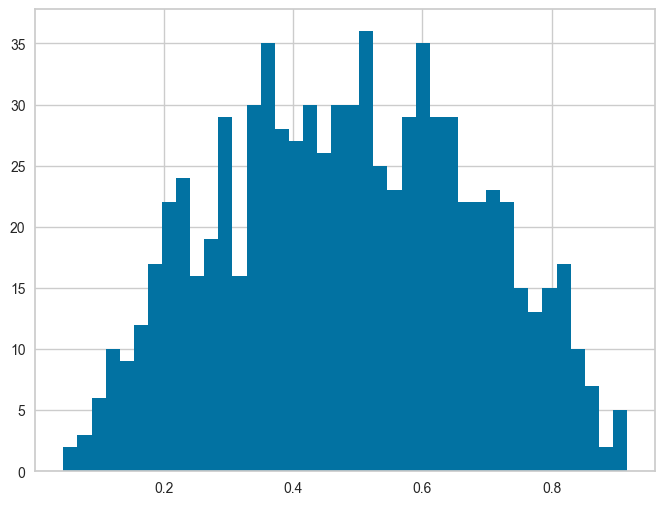

In [81]:
plt.rcParams['figure.figsize'] = 8.0, 6.0
plt.hist(est_t,bins=40)

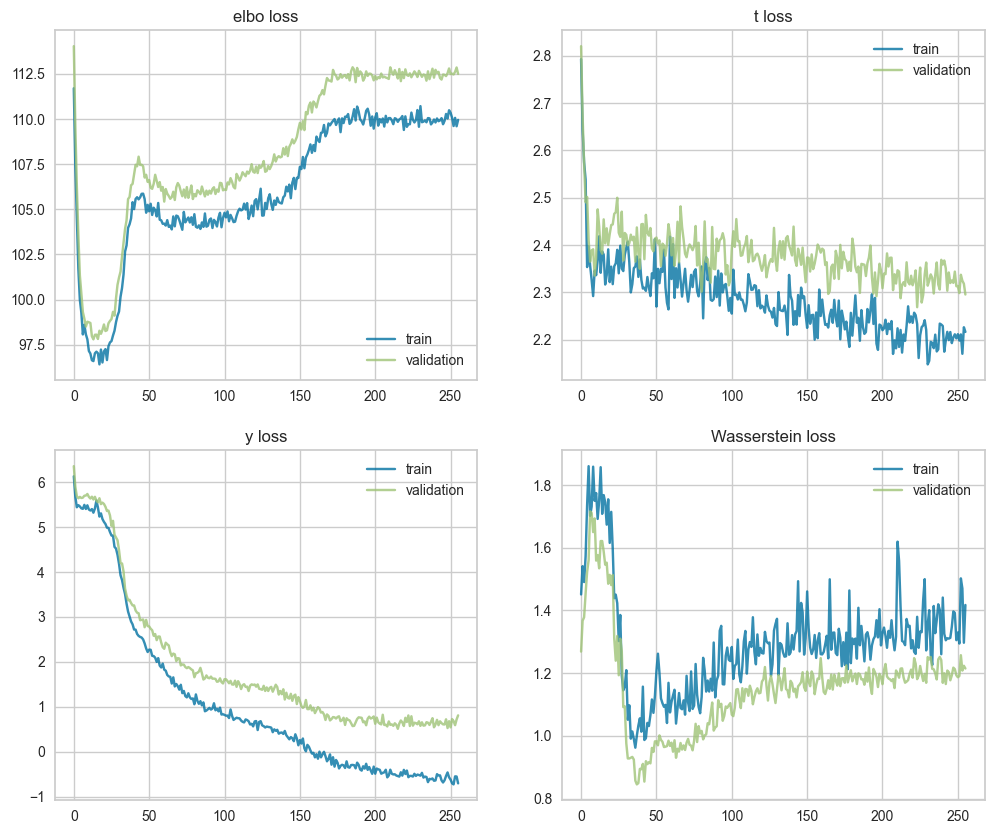

In [82]:
scale_num = x_train.shape[0]/x_test.shape[0]
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
plt.plot(np.array(trn_edvaefit), label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit)*scale_num, label = "validation", alpha = 0.8)
plt.title("elbo loss")
plt.legend()
plt.subplot(2,2,2)
plt.plot(np.array(trn_edvaefit_t)/args["alpha_t"], label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_t)/args["alpha_t"]*scale_num, label = "validation", alpha = 0.8)
plt.title("t loss")
plt.legend()
plt.subplot(2,2,3)
plt.plot(np.array(trn_edvaefit_y)/args["alpha_y"], label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_y)/args["alpha_y"]*scale_num, label = "validation", alpha = 0.8)
plt.title("y loss")
plt.legend()
plt.subplot(2,2,4)
plt.plot(np.array(trn_edvaefit_d)/args["alpha_d"], label = "train", alpha = 0.8)
plt.plot(np.array(val_edvaefit_d)/args["alpha_d"]*scale_num, label = "validation", alpha = 0.8)
plt.title("Wasserstein loss")
plt.legend()

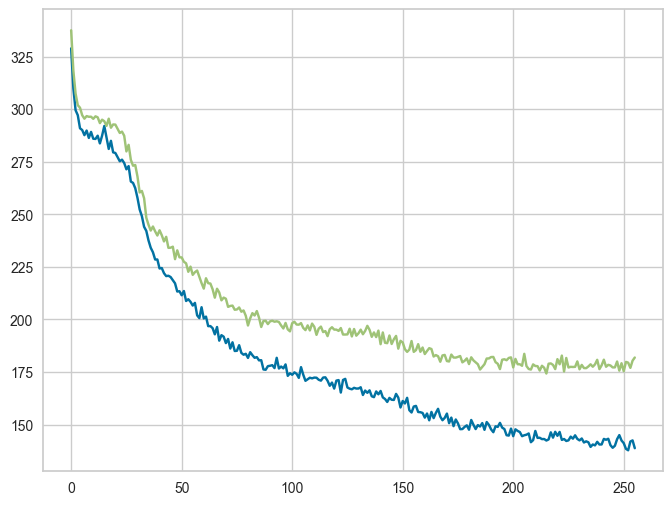

In [83]:
totalloss_tn = np.array(trn_edvaefit) + np.array(trn_edvaefit_t) + np.array(trn_edvaefit_y) + np.array(trn_edvaefit_d)
totalloss_vd = np.array(val_edvaefit) + np.array(val_edvaefit_t) + np.array(val_edvaefit_y) + np.array(val_edvaefit_d)
plt.plot(totalloss_tn)
plt.plot(totalloss_vd*scale_num)

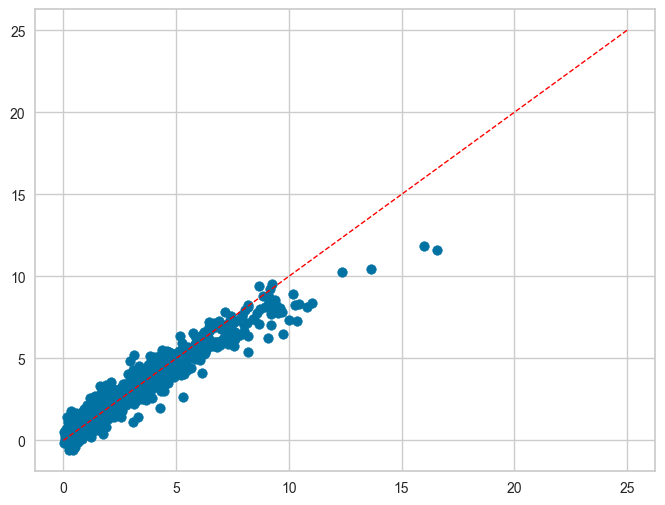

In [84]:
plt.figure(figsize=(8, 6))
plt.scatter(true_ite_test.numpy().squeeze(),est_ite.numpy().squeeze())
plt.plot([0,25],[0,25],color="red",linestyle="--",linewidth=1)

In [85]:
est_ite_tr,est_y0_tr,est_y1_tr,est_t_tr,muz_hat_tr,muzt_hat_tr,muzy_hat_tr,ite_gen_tr,t_gen_tr,y0gen_tr,y1gen_tr,TC_list_tr = edvae.ite(x_train, ym, ys)

tt=t_train.numpy().squeeze()
est_t_tr=est_t_tr.numpy()
yy0=est_y0_tr.detach().numpy()
yy1=est_y1_tr.detach().numpy()
yy_hat=yy1*tt+yy0*(1-tt)
yy=y_train*ys+ym
yy=yy.numpy().squeeze()
term1=est_ite_tr
term2=tt/est_t_tr-(1-tt)/(1-est_t_tr)
term3=yy-yy_hat
DR_pseudo = term1+term2*term3

R_m=yy1*est_t_tr+yy0*(1-est_t_tr)
R_e=est_t_tr
R_Yresid=yy-R_m
R_Dresid=tt-R_e
R_pseudo=R_Yresid/R_Dresid
R_weights=R_Dresid**2

resultdata={"edvae_ite":est_ite_tr,
            "pseudo outcome_DR":DR_pseudo,
            "pseudo outcome_R":R_pseudo,
            "pseudo outcome_R_w":R_weights,
            "propensity_hat":est_t_tr}
resultdata=pd.DataFrame(resultdata)
output=pd.concat([df_train.reset_index(drop=True),resultdata],axis=1)
# output.to_csv("C:/Users/PEK/Desktop/比較圖檔/edvae_to_metalearner_output.csv")

--------------------------------------------------------------------------------------------------------------------------------------------------------

'hidden_dim': 24,'num_layers': 4

In [86]:
pehe_train = np.sqrt(np.mean((true_ite_train.numpy().squeeze()-est_ite_tr.numpy().squeeze())**2))
pehe_test = np.sqrt(np.mean((true_ite_test.numpy().squeeze()-est_ite.numpy().squeeze())**2))
pehe_all = np.sqrt(np.mean((true_ite.numpy().squeeze()-est_ite_all.numpy().squeeze())**2))
print(f"Train:  {pehe_train}")
print(f"Test:  {pehe_test}")
print(f"ALL data:  {pehe_all}")
print(f"True ATE:  {true_ite.mean()}")
print(f"pred ATE:  {est_ite_all.mean()}")
print(abs(true_ite.mean()-est_ite_all.mean()))

Train:  0.6494951248168945
Test:  0.7336056232452393
ALL data:  0.666477382183075
True ATE:  2.980485200881958
pred ATE:  2.951047897338867
tensor(0.0294)


In [87]:
from sklearn.metrics import accuracy_score
a=est_t_all.numpy().copy()
a[(est_t_all>0.5).numpy()]=1
a[(est_t_all<=0.5).numpy()]=0
a_tr=est_t_tr.copy()
a_tr[(est_t_tr>0.5)]=1
a_tr[(est_t_tr<=0.5)]=0
a_ts=est_t.numpy().copy()
a_ts[(est_t>0.5).numpy()]=1
a_ts[(est_t<=0.5).numpy()]=0
aa = df["Treat"]
print(f"accuracy_Train:  {accuracy_score(np.array(t_train),a_tr)}")
print(f"accuracy_Test:  {accuracy_score(np.array(t_test),a_ts)}")
print(f"accuracy_all:  {accuracy_score(np.array(aa),a)}")

accuracy_Train:  0.743125
accuracy_Test:  0.705
accuracy_all:  0.73675


In [88]:
b=est_y1_all.numpy()*np.array(df["Treat"])+est_y0_all.numpy()*(1-np.array(df["Treat"]))
b_tr=est_y1_tr.numpy()*np.array(t_train)+est_y0_tr.numpy()*(1-np.array(t_train))
b_ts=est_y1.numpy()*np.array(t_test)+est_y0.numpy()*(1-np.array(t_test))
np.sqrt(np.mean((np.array(df["outcome"])-b)**2))
bb = df["outcome"]

print(f"mse_Train:  {np.sqrt(np.mean((np.array(y_train*ys+ym)-b_tr)**2))}")
print(f"mse_Test:  {np.sqrt(np.mean((np.array(y_test*ys+ym)-b_ts)**2))}")
print(f"mse_all:  {np.sqrt(np.mean((np.array(bb)-b)**2))}")

mse_Train:  0.9138978719711304
mse_Test:  1.187359094619751
mse_all:  0.9738429090435033


In [89]:
latentt=pd.DataFrame(muzt_hat_all)
latentt.columns=["zt1","zt2","zt3","zt4","zt5","zt6","zt7","zt8","zt9","zt10"]
latentc=pd.DataFrame(muz_hat_all)
latentc.columns=["zc1","zc2","zc3","zc4","zc5","zc6","zc7","zc8"]
latenty=pd.DataFrame(muzy_hat_all)
latenty.columns=["zy1","zy2"]
latentout=pd.concat([latentt,latentc,latenty],axis=1)
latentout.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/edvae_latentout.csv")

In [90]:
est_ite_all,est_y0_all,est_y1_all,est_t_all,muz_hat_all,muzt_hat_all,muzy_hat_all,ite_gen_all,t_gen_all,y0gen_all,y1gen_all,TC_list_all = edvae.ite(X, ym, ys)

tt=t.numpy().squeeze()
est_t_all=est_t_all.numpy()
yy0=est_y0_all.detach().numpy()
yy1=est_y1_all.detach().numpy()
yy_hat=yy1*tt+yy0*(1-tt)
yy=y
yy=yy.numpy().squeeze()
term1=est_ite_all
term2=tt/est_t_all-(1-tt)/(1-est_t_all)
term3=yy-yy_hat
DR_pseudo = term1+term2*term3

R_m=yy1*est_t_all+yy0*(1-est_t_all)
R_e=est_t_all
R_Yresid=yy-R_m
R_Dresid=tt-R_e
R_pseudo=R_Yresid/R_Dresid
R_weights=R_Dresid**2

resultdata={"edvae_ite":est_ite_all,
            "pseudo outcome_DR":DR_pseudo,
            "pseudo outcome_R":R_pseudo,
            "pseudo outcome_R_w":R_weights,
            "propensity_hat":est_t_all}
resultdata=pd.DataFrame(resultdata)
output=pd.concat([df.reset_index(drop=True),resultdata],axis=1)
output.to_csv("C:/Users/ASUS/Desktop/cg working/Variational autoencoder/vae_compare/edvae_to_metalearner_output.csv")

--------------------------------------------------------------------------------------------------------------------------------------------------------